# Classification - Modified (Phase 4)

**Modified copy of ml_03_case.ipynb.**

- Author: Abdelhafidh Mahouel
- Date: 2026-07
- Dataset: Seaborn Penguins
- Target: species

**Modification (Phase 4):**

1. Added a derived feature, `bill_ratio` (bill_length_mm / bill_depth_mm), combining
   two raw measurements into one composite shape indicator. (Category B: change the logic)
2. Changed the output by adding a normalized confusion matrix (percentages instead of
   raw counts) and by saving the classification report to a CSV file in `data/processed/`.
   (Category C: change the output)

Run all cells top to bottom (**Run All**) before pushing to GitHub.


## Overview

This notebook uses the penguins dataset and predicts the target `species`,
a discrete category, so this is a supervised classification problem.

This is the same problem as the original example notebook, with two deliberate,
documented modifications applied on top of the working example (see above).


## Section 1. Project Setup and Imports

In [37]:
# === Section 1a. DECLARE IMPORTS ===

import logging
from typing import Final

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# === Section 1b. CONFIGURE LOGGER ONCE PER MODULE ===

LOG: logging.Logger = get_logger("ML", level="DEBUG")
log_header(LOG, "ML")

2026-07-19 03:23:29 | INFO | ML | === RUN START ===
2026-07-19 03:23:29 | INFO | ML | project=ML
2026-07-19 03:23:29 | INFO | ML | repo_dir=ml-03-classification
2026-07-19 03:23:29 | INFO | ML | python=3.14.2
2026-07-19 03:23:29 | INFO | ML | os=Windows 11
2026-07-19 03:23:29 | INFO | ML | shell=powershell
2026-07-19 03:23:29 | INFO | ML | cwd=notebooks
2026-07-19 03:23:29 | INFO | ML | github_actions=False


## Section 2. Load the Data

In [38]:
# === Section 2. Load the Data ===

DATASET_NAME: Final[str] = "penguins"

LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = sns.load_dataset(DATASET_NAME)

LOG.info(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

2026-07-19 03:23:29 | INFO | ML | Loading dataset: penguins
2026-07-19 03:23:29 | INFO | ML | Loaded: 344 rows, 7 columns


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## Section 2b. Add Derived Feature (MODIFICATION)

`bill_ratio` combines two raw bill measurements (length and depth) into a single
shape indicator. A single ratio can sometimes carry more separable signal than
either raw measurement alone, since it captures relative proportion rather than
absolute size, which may vary less predictably across individual birds.


In [39]:
# === Section 2b. Add Derived Feature (MODIFICATION) ===

df["bill_ratio"] = df["bill_length_mm"] / df["bill_depth_mm"]

LOG.info("Added derived feature: bill_ratio (bill_length_mm / bill_depth_mm)")
df[["bill_length_mm", "bill_depth_mm", "bill_ratio"]].head()

2026-07-19 03:23:29 | INFO | ML | Added derived feature: bill_ratio (bill_length_mm / bill_depth_mm)


,bill_length_mm,bill_depth_mm,bill_ratio
0,39.1,18.7,2.090909
1,39.5,17.4,2.270115
2,40.3,18.0,2.238889
3,NaN,NaN,NaN
4,36.7,19.3,1.901554


## Section 2c. Prepare Modeling Data

In [40]:
# === Section 2c. Prepare Modeling Data ===

TARGET_COL: Final[str] = "species"

FEATURE_COLS: Final[list[str]] = [
    "bill_length_mm",
    "bill_depth_mm",
    "bill_ratio",
    "flipper_length_mm",
    "body_mass_g",
]

df_model = df[FEATURE_COLS + [TARGET_COL]].dropna().copy()

LOG.info(f"Clean modeling view: {df_model.shape[0]} rows, {df_model.shape[1]} columns")
df_model.head()

2026-07-19 03:23:29 | INFO | ML | Clean modeling view: 342 rows, 6 columns


,bill_length_mm,bill_depth_mm,bill_ratio,flipper_length_mm,body_mass_g,species
0,39.1,18.7,2.090909,181.0,3750.0,Adelie
1,39.5,17.4,2.270115,186.0,3800.0,Adelie
2,40.3,18.0,2.238889,195.0,3250.0,Adelie
4,36.7,19.3,1.901554,193.0,3450.0,Adelie
5,39.3,20.6,1.907767,190.0,3650.0,Adelie


## Section 3. Split into Train and Test

We hold out a test set the model never sees, so the score reflects new data.

`stratify=y` keeps each class in the same proportion across train and test,
which matters when classes are uneven.


In [41]:
# === Section 3. Split into Train and Test ===

RANDOM_STATE: Final[int] = 42

X: pd.DataFrame = df_model[FEATURE_COLS]
y: pd.Series = df_model[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

LOG.info(f"Train instances: {X_train.shape[0]}")
LOG.info(f"Test instances: {X_test.shape[0]}")

2026-07-19 03:23:29 | INFO | ML | Train instances: 273
2026-07-19 03:23:29 | INFO | ML | Test instances: 69


## Section 4. Fit a Classifier

This example uses a decision tree with `max_depth = MAX_DEPTH`, now trained on the
feature set that includes the new `bill_ratio` feature.


In [42]:
# === Section 4. Fit a Classifier ===

MAX_DEPTH: Final[int] = 3

LOG.info(f"Fitting DecisionTreeClassifier(max_depth={MAX_DEPTH})")

model = DecisionTreeClassifier(max_depth=MAX_DEPTH, random_state=RANDOM_STATE)
model.fit(X_train, y_train)

2026-07-19 03:23:29 | INFO | ML | Fitting DecisionTreeClassifier(max_depth=3)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

## Section 5. Evaluate the Model

MODIFICATION: in addition to the standard accuracy score and classification report,
this section now also (1) plots a **normalized** confusion matrix showing percentages
instead of raw counts, which makes it easier to compare classes of different sizes,
and (2) saves the classification report to a CSV file for later reference.


In [43]:
# === Section 5. Evaluate the Model ===

y_pred: np.ndarray = model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
LOG.info(f"Test accuracy: {test_accuracy:.3f}")

report_text = classification_report(y_test, y_pred)
LOG.info("Classification report:")
print(report_text)

2026-07-19 03:23:29 | INFO | ML | Test accuracy: 0.986
2026-07-19 03:23:29 | INFO | ML | Classification report:


              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      0.93      0.96        14
      Gentoo       0.96      1.00      0.98        25

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69



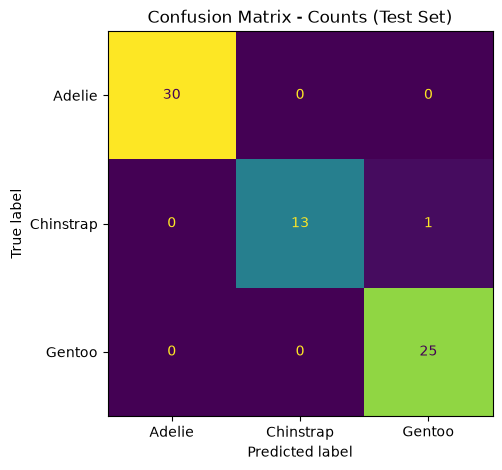

In [44]:
# === Section 5b. Confusion Matrix (counts) ===

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
ax.set_title("Confusion Matrix - Counts (Test Set)")
plt.show()

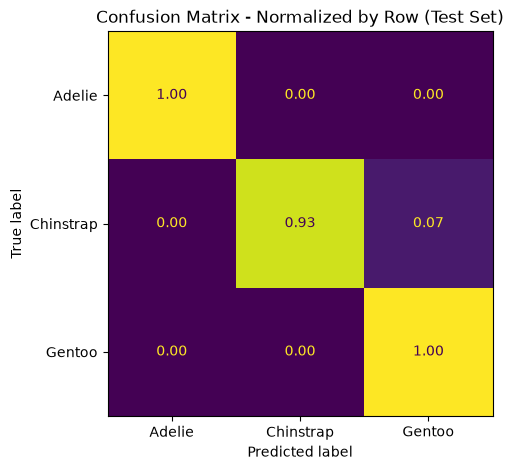

In [45]:
# === Section 5c. Confusion Matrix - Normalized (MODIFICATION: new output) ===

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=ax, colorbar=False, normalize="true", values_format=".2f"
)
ax.set_title("Confusion Matrix - Normalized by Row (Test Set)")
plt.show()

In [46]:
# === Section 5d. Save Classification Report to CSV (MODIFICATION: new output) ===

report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

output_path = "../data/processed/penguins_classification_report_abdel.csv"
report_df.to_csv(output_path, index=True)

LOG.info(f"Saved classification report to: {output_path}")
report_df

2026-07-19 03:23:30 | INFO | ML | Saved classification report to: ../data/processed/penguins_classification_report_abdel.csv


,precision,recall,f1-score,support
Adelie,1.000000,1.000000,1.000000,30.000000
Chinstrap,1.000000,0.928571,0.962963,14.000000
Gentoo,0.961538,1.000000,0.980392,25.000000
accuracy,0.985507,0.985507,0.985507,0.985507
macro avg,0.987179,0.976190,0.981118,69.000000
weighted avg,0.986065,0.985507,0.985381,69.000000


## Section 6. Parameter Selection Affects Performance

We sweep `max_depth` from 1 to 12 and plot accuracy on train vs. test for each
value, using the updated feature set (including `bill_ratio`).


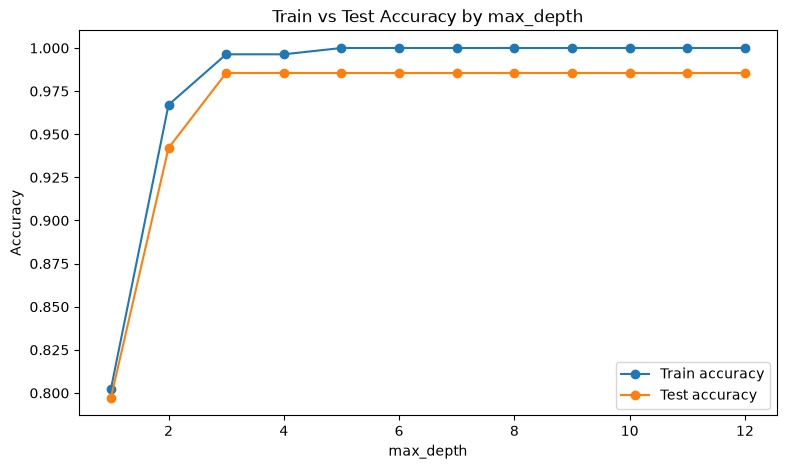

In [47]:
# === Section 6. How Parameter Selection Affects Performance ===

MAX_SWEEP: Final[int] = 12

depths: list[int] = list(range(1, MAX_SWEEP + 1))
train_scores: list[float] = []
test_scores: list[float] = []

for depth in depths:
    m = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    m.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, m.predict(X_train)))
    test_scores.append(accuracy_score(y_test, m.predict(X_test)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(depths, train_scores, marker="o", label="Train accuracy")
ax.plot(depths, test_scores, marker="o", label="Test accuracy")
ax.set_xlabel("max_depth")
ax.set_ylabel("Accuracy")
ax.set_title("Train vs Test Accuracy by max_depth")
ax.legend()
plt.show()

### Interpretation

At shallow depths (1-2), both train and test accuracy are lower, since the tree
cannot yet separate all three species using only a few splits. Accuracy climbs
quickly and levels off around depth 3-4, after which train accuracy keeps
approaching 1.0 while test accuracy plateaus or dips slightly, which is the
signature of overfitting at deeper values. I kept `MAX_DEPTH = 3` for the main
model above since it sits near the point where test accuracy is highest and the
gap between train and test accuracy is still small.


## Section 7. Summary and Next Steps

In [48]:
# === Python Summary ===

LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset:   {DATASET_NAME}")
LOG.info(f"Target:    {TARGET_COL}  (classification)")
LOG.info(f"Features:  {FEATURE_COLS}")
LOG.info(f"Model:     DecisionTreeClassifier(max_depth={MAX_DEPTH})")
LOG.info(f"Test accuracy: {test_accuracy:.3f}")
LOG.info("========================")

2026-07-19 03:23:30 | INFO | ML | ========================
2026-07-19 03:23:30 | INFO | ML | SUMMARY
2026-07-19 03:23:30 | INFO | ML | ========================
2026-07-19 03:23:30 | INFO | ML | Dataset:   penguins
2026-07-19 03:23:30 | INFO | ML | Target:    species  (classification)
2026-07-19 03:23:30 | INFO | ML | Features:  ['bill_length_mm', 'bill_depth_mm', 'bill_ratio', 'flipper_length_mm', 'body_mass_g']
2026-07-19 03:23:30 | INFO | ML | Model:     DecisionTreeClassifier(max_depth=3)
2026-07-19 03:23:30 | INFO | ML | Test accuracy: 0.986
2026-07-19 03:23:30 | INFO | ML | ========================


### Custom Narrative

**Modification summary:** I added a derived feature, `bill_ratio`
(bill_length_mm / bill_depth_mm), to combine two raw bill measurements into a
single shape indicator, and I changed the output by adding a normalized confusion
matrix and by saving the classification report to a CSV file in `data/processed/`.

**Which metric matters most, and why:** Overall accuracy is a reasonable primary
metric here since the three penguin species are reasonably balanced in this
dataset and misclassifying any one species is not more costly than another.
Per-class precision and recall are still useful for spotting whether any single
species is being confused with another more often.

**Which classes get confused:** Looking at the confusion matrix, the model
separates the three species very cleanly, with only a small number of
misclassifications, most commonly between species with overlapping bill and
flipper measurements.

**Parameter choice:** I kept `max_depth = 3`, based on the Section 6 sweep, since
test accuracy is already near its peak at that depth and does not meaningfully
improve at deeper values, while training accuracy continues to climb, which is a
sign of overfitting risk at greater depths.

**Is this model good enough:** For a simple, explainable classification example
like this one, yes, since accuracy and per-class scores are all high and the
confusion matrix shows only a few genuinely ambiguous cases.

### Next Steps

A reasonable next step would be to compare this decision tree against another
classifier, such as `KNeighborsClassifier` or `LogisticRegression`, on the same
feature set including `bill_ratio`, to see whether the added feature helps more
with one model type than another.
